# Buffer Categories Demo

## Setup

In [1]:
from shelterbelts.utils.filepaths import get_filename
from shelterbelts.utils.visualisation import visualise_categories_sidebyside, visualise_categories
from shelterbelts.indices.buffer_categories import buffer_categories
from shelterbelts.indices.buffer_categories import buffer_categories_cmap, buffer_categories_labels

# Example data
cover_file = get_filename('g2_26729_cover_categories.tif')
gullies_file = get_filename('g2_26729_hydrolines.tif')
ridges_file = get_filename('g2_26729_DEM-S_ridges.tif')
roads_file = get_filename('g2_26729_roads.tif')

In [2]:
!pwd

/home/147/cb8590


## Default Parameters (gullies only)

In [3]:
ds_default = buffer_categories(cover_file, gullies_file)
ds_default

Saved: ./TEST_buffer_categories.tif
Saved: ./TEST_buffer_categories.png


<xarray.Dataset> Size: 124kB
Dimensions:            (x: 201, y: 201)
Coordinates:
  * x                  (x) float64 2kB 6.3e+05 6.3e+05 ... 6.32e+05 6.32e+05
  * y                  (y) float64 2kB 6.196e+06 6.196e+06 ... 6.194e+06
    spatial_ref        int64 8B 0
Data variables:
    cover_categories   (y, x) uint8 40kB 12 12 12 12 12 12 ... 31 31 31 31 31 31
    gullies            (y, x) uint8 40kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    buffer_categories  (y, x) uint8 40kB 12 12 12 12 12 12 ... 31 31 31 31 31 31

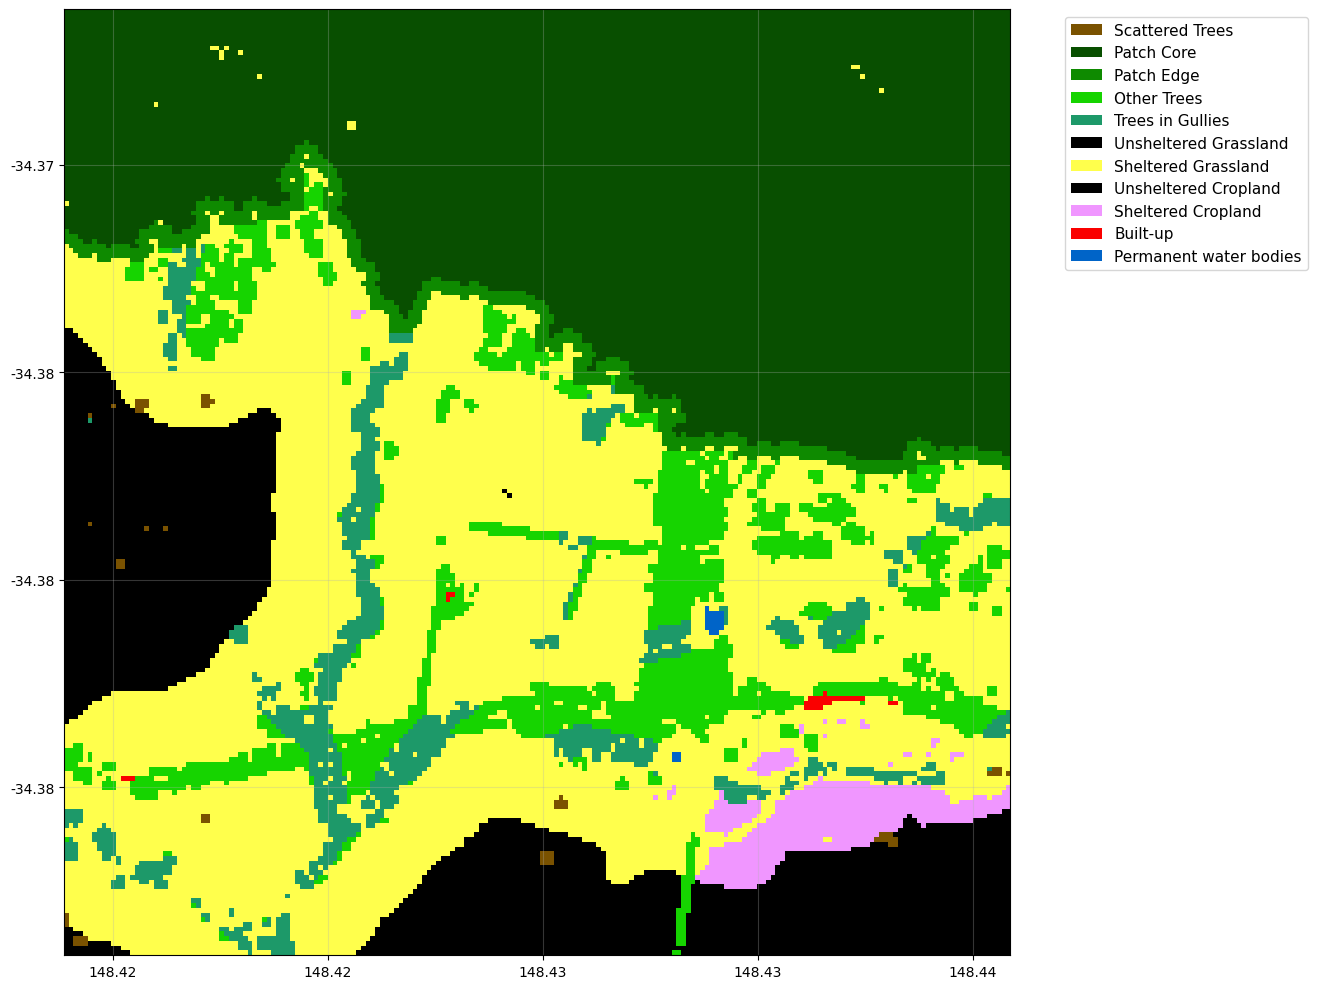

In [4]:
visualise_categories(
    ds_default['buffer_categories'],
    colormap=buffer_categories_cmap,
    labels=buffer_categories_labels
)

## Changing the buffer_width

The `buffer_width` parameter sets how many pixels away from a feature (gully, ridge, road) still count as within the buffer.

Saved: ./TEST_buffer_categories.tif
Saved: ./TEST_buffer_categories.png
Saved: ./TEST_buffer_categories.tif
Saved: ./TEST_buffer_categories.png


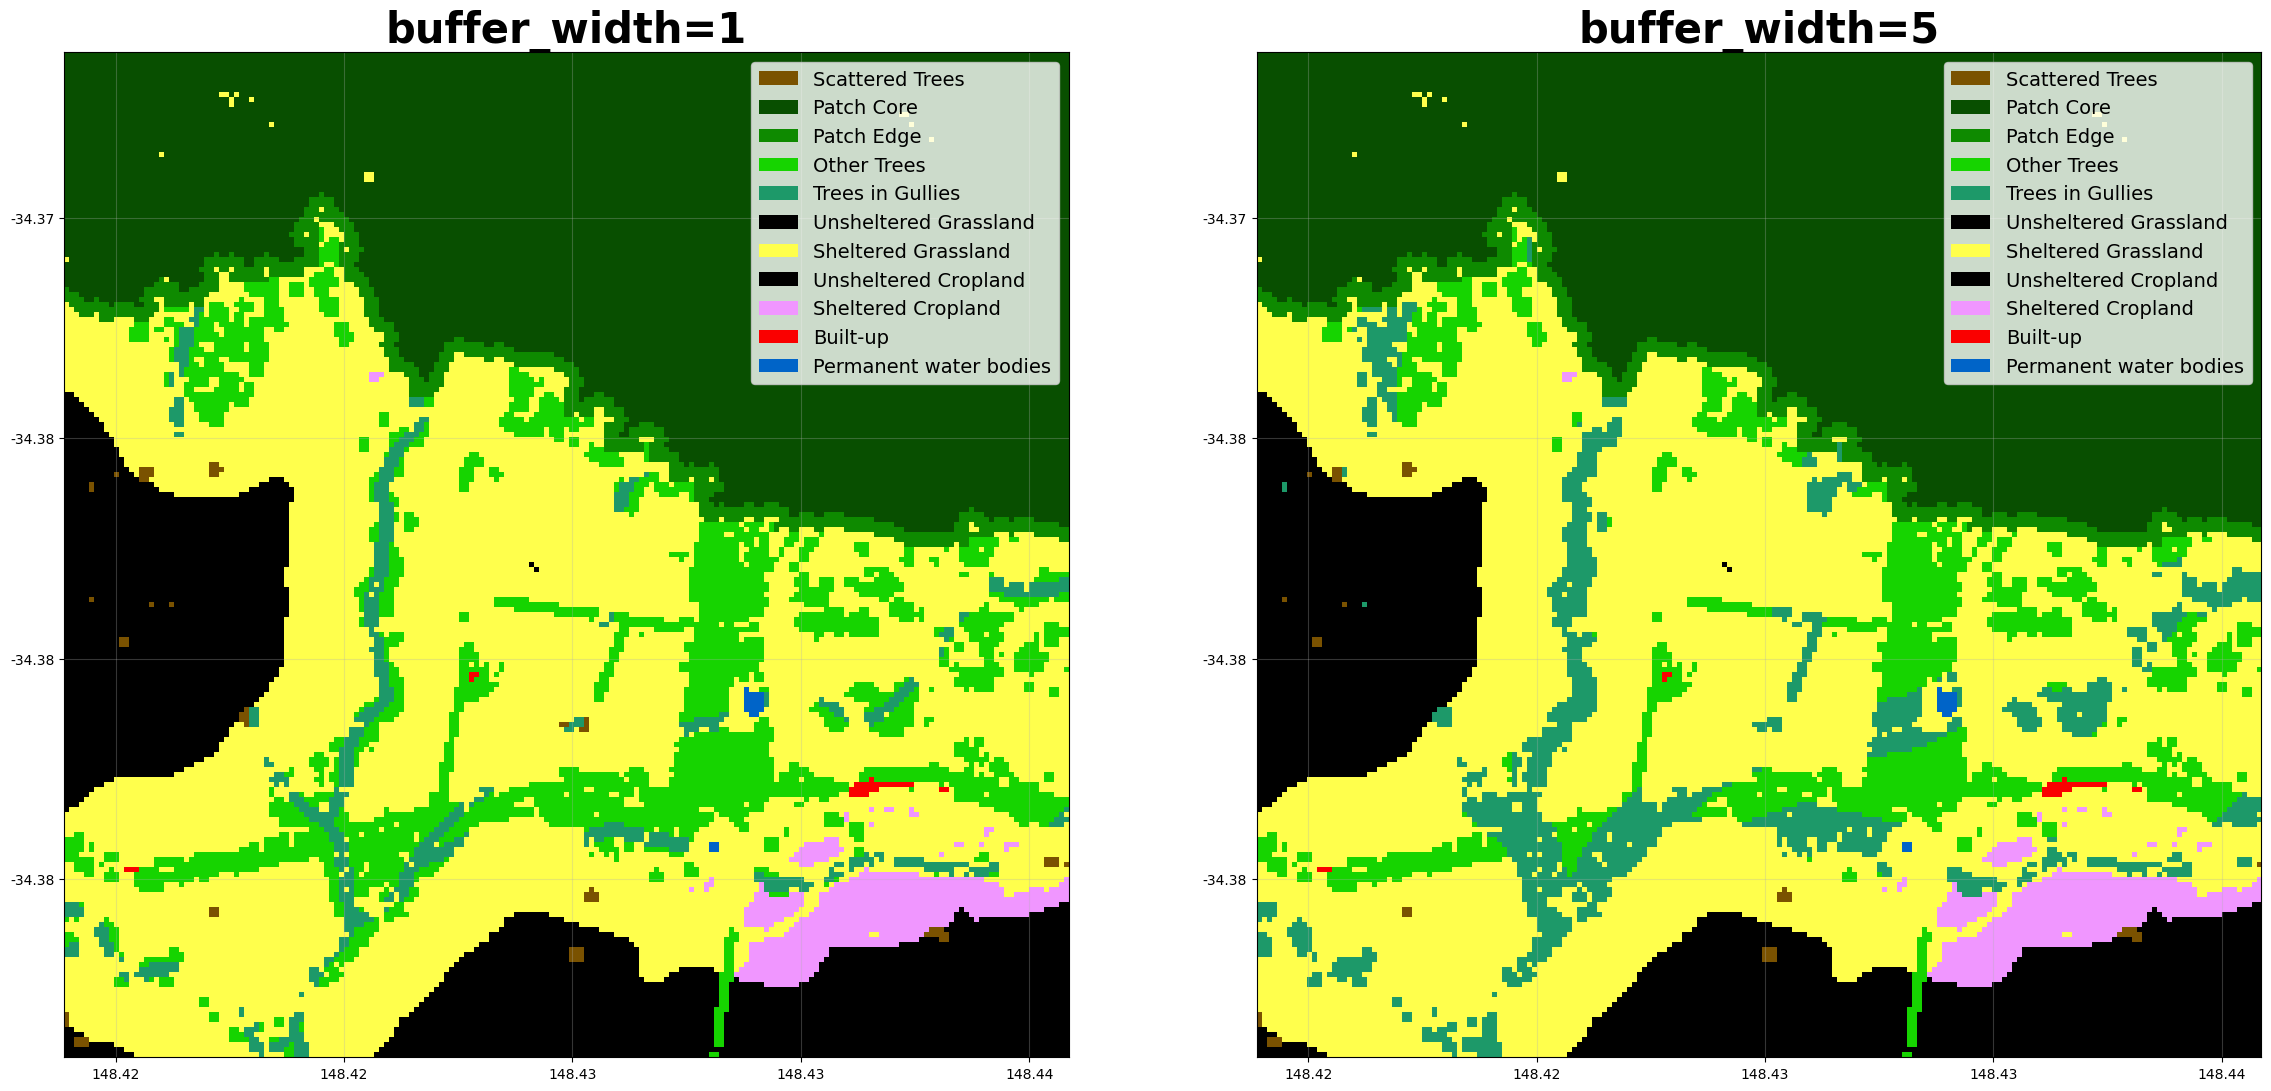

In [5]:
ds1 = buffer_categories(cover_file, gullies_file, buffer_width=1)
ds2 = buffer_categories(cover_file, gullies_file, buffer_width=5)
visualise_categories_sidebyside(
    ds1['buffer_categories'], ds2['buffer_categories'],
    colormap=buffer_categories_cmap, labels=buffer_categories_labels,
    title1="buffer_width=1", title2="buffer_width=5"
)

## Adding ridges and roads

Providing `ridges_data` and `roads_data` adds ridge buffer and road buffer categories.

Saved: ./gullies_and_roads_buffer_categories.tif
Saved: ./gullies_and_roads_buffer_categories.png
Saved: ./all_buffers_buffer_categories.tif
Saved: ./all_buffers_buffer_categories.png


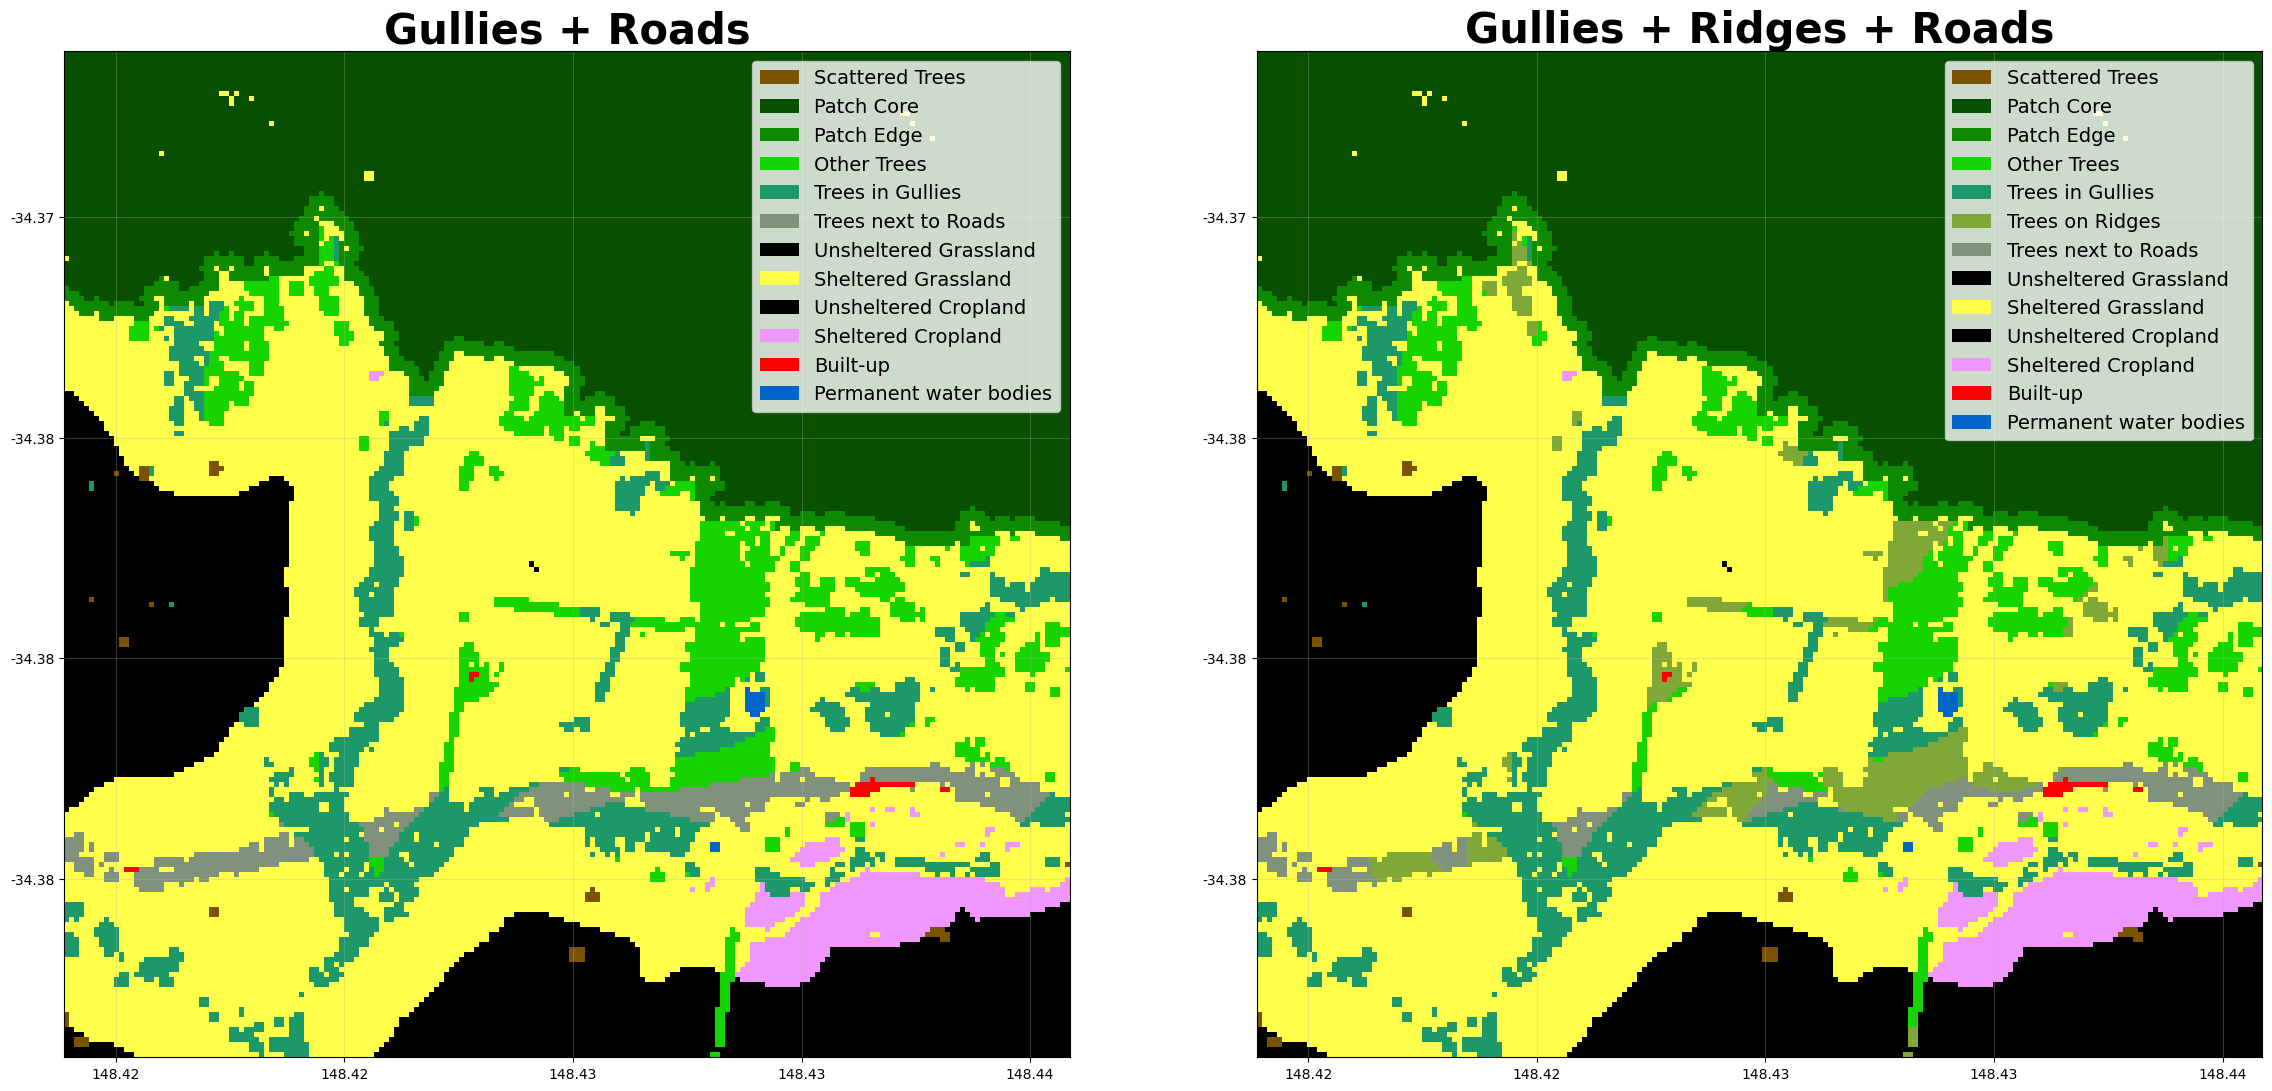

In [6]:
ds_gullies = buffer_categories(cover_file, gullies_file, roads_data=roads_file, stub='gullies_and_roads', buffer_width=5)
ds_all = buffer_categories(cover_file, gullies_file, ridges_data=ridges_file, roads_data=roads_file, stub='all_buffers', buffer_width=5)
visualise_categories_sidebyside(
    ds_gullies['buffer_categories'], ds_all['buffer_categories'],
    colormap=buffer_categories_cmap, labels=buffer_categories_labels,
    title1="Gullies + Roads", title2="Gullies + Ridges + Roads"
)

## Command Line Interface

In [7]:
!python -m shelterbelts.indices.buffer_categories --help

usage: buffer_categories.py [-h] [--ridges_data RIDGES_DATA]
                            [--roads_data ROADS_DATA] [--outdir OUTDIR]
                            [--stub STUB] [--buffer_width BUFFER_WIDTH]
                            [--no-savetif] [--no-plot]
                            cover_data gullies_data

positional arguments:
  cover_data            Integer tif file generated by cover_categories.py
  gullies_data          Boolean tif file generated by either hydrolines.py or
                        catchments.py

options:
  -h, --help            show this help message and exit
  --ridges_data RIDGES_DATA
                        Boolean tif file generated by catchments.py
  --roads_data ROADS_DATA
                        Boolean tif file generated by apis/osm.py
  --outdir OUTDIR       Output directory for saving results (default: current
                        directory)
  --stub STUB           Prefix for output filenames (default: TEST)
  --buffer_width BUFFER_WIDTH
          

In [8]:
!python -m shelterbelts.indices.buffer_categories {cover_file} {gullies_file} --roads_data {roads_file} --buffer_width 4 --stub command_line

Saved: ./command_line_buffer_categories.tif
Saved: ./command_line_buffer_categories.png


### Cleanup
Remove the output files created by this notebook

In [10]:
# !rm *.tif
# !rm *.png
# !rm *.xml  # These get generated if you load the tifs in QGIS

rm: cannot remove '*.xml': No such file or directory
